In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
import seaborn as sns

In [16]:
df = pd.read_csv('Data.csv')
df.head()

,HouseSize,DistanceToCity,Location,Price
0,NaN,22.92,B,20.74
1,48.6,27.90,B,19.35
2,NaN,28.29,A,23.30
3,65.2,25.99,A,25.37
4,47.7,29.19,A,19.66


In [17]:
df.isnull().sum()


HouseSize         5
DistanceToCity    5
Location          0
Price             0
dtype: int64

In [18]:
num_cols = df.select_dtypes('number').columns
print(num_cols.tolist())

['HouseSize', 'DistanceToCity', 'Price']


In [19]:
num_imp = SimpleImputer()

In [20]:
df[num_cols] = num_imp.fit_transform(df[num_cols])
df

,HouseSize,DistanceToCity,Location,Price
0,53.026316,22.92,B,20.74
1,48.600000,27.90,B,19.35
2,53.026316,28.29,A,23.30
3,65.200000,25.99,A,25.37
4,47.700000,29.19,A,19.66
...,...,...,...,...
95,115.400000,81.93,C,45.12
96,133.000000,75.58,C,50.43
97,132.600000,80.77,B,50.44
98,130.100000,80.29,C,52.66


In [21]:
df.isnull().sum()

HouseSize         0
DistanceToCity    0
Location          0
Price             0
dtype: int64

In [22]:
df['Location'].value_counts()

Location
B    37
A    33
C    30
Name: count, dtype: int64

In [23]:
from sklearn.preprocessing import OneHotEncoder
cat_cols  = ['Location']
ohe = OneHotEncoder(drop='first')
X_encoded = ohe.fit_transform(df[cat_cols]).toarray()
X_encoded_df = pd.DataFrame(X_encoded, columns=ohe.get_feature_names_out(cat_cols))
X_encoded_df

,Location_B,Location_C
0,1.0,0.0
1,1.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
95,0.0,1.0
96,0.0,1.0
97,1.0,0.0
98,0.0,1.0


In [24]:
clean_df = pd.concat([df, X_encoded_df], axis=1).drop(cat_cols, axis=1)
clean_df

,HouseSize,DistanceToCity,Price,Location_B,Location_C
0,53.026316,22.92,20.74,1.0,0.0
1,48.600000,27.90,19.35,1.0,0.0
2,53.026316,28.29,23.30,0.0,0.0
3,65.200000,25.99,25.37,0.0,0.0
4,47.700000,29.19,19.66,0.0,0.0
...,...,...,...,...,...
95,115.400000,81.93,45.12,0.0,1.0
96,133.000000,75.58,50.43,0.0,1.0
97,132.600000,80.77,50.44,1.0,0.0
98,130.100000,80.29,52.66,0.0,1.0


In [25]:
from sklearn.preprocessing import StandardScaler
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
clean_df[num_cols] = scaler.fit_transform(clean_df[num_cols])
clean_df

,HouseSize,DistanceToCity,Price,Location_B,Location_C
0,0.000000,-0.835721,-0.217001,1.0,0.0
1,-0.229787,-0.404456,-0.416757,1.0,0.0
2,0.000000,-0.370682,0.150895,0.0,0.0
3,0.631984,-0.569861,0.448373,0.0,0.0
4,-0.276510,-0.292743,-0.372207,0.0,0.0
...,...,...,...,...,...
95,3.238062,4.274512,3.286631,0.0,1.0
96,4.151747,3.724605,4.049727,0.0,1.0
97,4.130981,4.174057,4.051164,1.0,0.0
98,4.001196,4.132489,4.370199,0.0,1.0


In [26]:
X = clean_df.drop('Price', axis=1)
y = df['Price']

In [27]:
x = clean_df.drop('Price', axis=1)
y = clean_df['Price']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)   

In [29]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
y_pred = regressor.predict(X_test)

In [31]:
from joblib import dump, load # dump and load are used to save and load the model respectively
with open('models/multi_linear_model.joblib', 'wb') as f:
    dump(regressor, f)
    print("Model dumped successfully.")
    

Model dumped successfully.


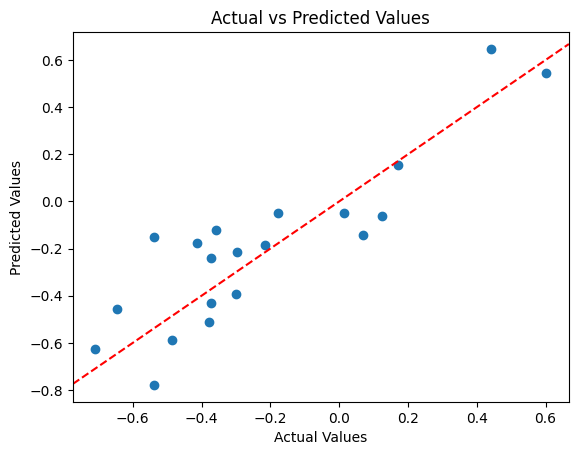

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(y_test, y_pred)
ax.axline((0, 0), slope=1, color="red", linestyle="--", label="y = x")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.show()